In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_project.config.config import load_config 
from phd_project.scripts.WP1_ground_motion_set.gm_selection import (
    preliminary_record_selection,
    optimise_record_selection,
)

from phd_project.scripts.WP1_ground_motion_set.setup_AvgSA06_gm_selection import setup_AvgSA06_gcim_gm_selection

cfg = load_config()

C:\Users\clemettn\Documents\phd\phd_project\scripts\WP1_ground_motion_set\gm_selection.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# AvgSA([0, 6])

In [3]:
# file paths:
gcim_dist_fp = cfg["proc_data"]["gcim_dists"] / f"gcim_dist_AvgSA_06.pickle"
preliminary_selection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_prelim_selection.pickle"
optimised_selection_rd1_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_optimised_selection_rd01.pickle"

preliminary_reselection_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_prelim_reselection.pickle"
optimised_selection_rd2_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_optimised_selection_rd02.pickle"
optimised_selection_rd3_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_optimised_selection_rd03.pickle"

esm_records_to_download_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_esm_records_to_download.csv"
ngasub_records_to_download_fp = cfg["proc_data"]["gm_selection"] / f"AvgSA_06_ngasub_records_to_download.csv"

# other stuff:
rng_seed = 1

LOAD_RS_IF_EXISTS = False
LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS = False

In [4]:
# set up the record selection
site_poe_disaggs, disagg_stats, site_model, basic_selection_ctx, gm_db = setup_AvgSA06_gcim_gm_selection()

# load the gcim distributions
if gcim_dist_fp.is_file():
    with open(gcim_dist_fp, "rb") as file:
        gcim_dists = pickle.load(file)
    print("Existing GCIM distribution data loaded...")
else:
    print("No existing GCIM distribution data found...")

Existing GCIM distribution data loaded...


## Preliminary Selection

 First go a preliminary selection. Using the Tarbali and Bradley recommendations for bounds on causal parameters.

In [5]:
only_select = []

preliminary_ensembles, prelim_ensembles_not_passing, no_preliminary_ensembles, _ = preliminary_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_selection_ctx, 
    site_model, 
    rng_seed, 
    preliminary_selection_fp=preliminary_selection_fp, 
    only_select=only_select, 
    load_rs_if_exists=LOAD_RS_IF_EXISTS)

Selecting GM Ensembles:   0%|          | 0/360 [00:00<?, ?it/s]

Sub-Optimal! - Preliminary ensembles do not pass for 85 combinations of site and poe
No preliminary ensembles found for 2 combinations of site and poe


In [6]:
no_preliminary_ensembles

[(30, np.float64(0.000201)), (30, np.float64(0.0001))]

## Optimisation of Ensembles

### Round 1

Optimisation using the same parameters as the original selection. This will optimise the ensembles that didn't pass the preliminary selection.

In [7]:
only_optimise = prelim_ensembles_not_passing

optimised_ensembles, optimised_ensembles_not_passing_rd1 = optimise_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_selection_ctx, 
    site_model, 
    preliminary_ensembles,
    optimised_selection_fp=optimised_selection_rd1_fp,
    only_optimise=only_optimise,
    shuffle=False,
    rng_seed=rng_seed, 
    load_rs_if_exists=LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS)

  0%|          | 0/85 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

...

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Sub-Optimal! - Optimised ensembles do not pass for 30 combinations of site and poe


The ensembles that are still failing can be optimised considering looser bounds on the causal parameters. Before doing so all sites for which no preliminary ensemble was found need to be reselected considering these looser bounds.

## Reselection

Reselection is performed considering no bound on the distance.

In [8]:
only_select = no_preliminary_ensembles

basic_reselection_ctx = basic_selection_ctx.copy()
basic_reselection_ctx["d_bound_model"] = None

reselected_ensembles, reselected_ensembles_not_passing, no_reselected_ensembles, _ = preliminary_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    basic_reselection_ctx, 
    site_model, 
    rng_seed, 
    preliminary_selection_fp=preliminary_reselection_fp, 
    only_select=only_select, 
    load_rs_if_exists=LOAD_RS_IF_EXISTS)

Selecting GM Ensembles:   0%|          | 0/2 [00:00<?, ?it/s]

Sub-Optimal! - Preliminary ensembles do not pass for 2 combinations of site and poe


In [9]:
# combine the reselected ensemble with the other preliminary ensembles
for k, v in reselected_ensembles.items():
    preliminary_ensembles[k] = v

## Optimisation

### Round 2

In [10]:
only_optimise = optimised_ensembles_not_passing_rd1

rd2_basic_selection_ctx = basic_selection_ctx.copy()
rd2_basic_selection_ctx["d_bound_model"] = None
rd2_basic_selection_ctx["vs30_bound_model"] = None

optimised_ensembles_rd2, optimised_ensembles_not_passing_rd2 = optimise_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    rd2_basic_selection_ctx, 
    site_model, 
    preliminary_ensembles,
    optimised_selection_fp=optimised_selection_rd2_fp,
    only_optimise=only_optimise,
    shuffle=False,
    rng_seed=rng_seed, 
    load_rs_if_exists=LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS)

  0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

...

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Sub-Optimal! - Optimised ensembles do not pass for 3 combinations of site and poe


In [11]:
for e in optimised_ensembles_not_passing_rd2:
    print(e, optimised_ensembles_rd2[e]["ks_failed_ims"])

(4, np.float64(0.0001)) ['SA(6.0)']
(23, np.float64(0.000201)) ['SA(6.0)']
(23, np.float64(0.0001)) ['RSD595', 'SA(6.0)']


### Round 3

A single site is still not passing although it is very close. Several options exist. We could shuffle the database and or the ensemble to try and find a better local optimisation, or we can run the optimisation again with no bounds on the magnitude as well.

In [12]:
only_optimise = optimised_ensembles_not_passing_rd2

rd3_basic_selection_ctx = basic_selection_ctx.copy()
rd3_basic_selection_ctx["m_bound_model"] = None
rd3_basic_selection_ctx["d_bound_model"] = None
rd3_basic_selection_ctx["vs30_bound_model"] = None

optimised_ensembles_rd3, optimised_ensembles_not_passing_rd3 = optimise_record_selection(
    site_poe_disaggs, 
    disagg_stats, 
    gcim_dists, 
    gm_db, 
    rd3_basic_selection_ctx, 
    site_model, 
    preliminary_ensembles,
    optimised_selection_fp=optimised_selection_rd3_fp,
    only_optimise=only_optimise,
    shuffle=False,
    rng_seed=rng_seed, 
    load_rs_if_exists=LOAD_OPTIMISED_ENSEMBLES_IF_EXISTS)

  0%|          | 0/3 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

Optimizing Ensemble Slots:   0%|          | 0/30 [00:00<?, ?it/s]

OK! - Optimised ensembles pass for all combinations of site and poe


When all of the optimisations have passed combine them

In [13]:
final_ensembles = preliminary_ensembles.copy()
final_ensembles.update(optimised_ensembles)
final_ensembles.update(optimised_ensembles_rd2)
final_ensembles.update(optimised_ensembles_rd3)

# Post-Processing

In [14]:
# Save the best ensembles in the results folder
RESULT_FOLDER = cfg["results"]["AvgSA_06_record_selection"]

poe_2_stripe_num_map = {poe:ii+1 for ii, poe in enumerate(sorted(disagg_stats["poe"].unique(), reverse=True))}

for (site, poe), ensemble in final_ensembles.items():

    if not ensemble["ks_passed"]:
        print(f"No valid ensemble: Site {site} - poe = {poe}")
        continue
    
    tag = f"site_{site}__stripe_{poe_2_stripe_num_map[poe]}"
    
    # Add the gcim_quantiles from the result
    ensemble["gcim_quantiles"] = gcim_dists[(site, poe)]["stats"]

    # calculate the trt %'s
    trt_stats = pd.DataFrame(
        ensemble["recs"].groupby(("metadata", "trt")).size())
    trt_stats.columns = ["count"]
    trt_stats["proportions"] = np.round(trt_stats["count"] / \
                                        trt_stats["count"].sum(), 3)
    ensemble["trt_stats"] = trt_stats

    # Surface RSN + a stable record identifier and JSON filename per record.
    recs = ensemble["recs"]
    is_ngasub = recs[("metadata", "database")] == "NGASub"

    # RSN: already present as metadata.index for NGASub; NA for ESM.
    recs[("metadata", "RSN")] = (
        recs[("metadata", "index")].astype("string").where(is_ngasub)
    )

    # record_identifier: ESM uses event/station/location; NGASub uses the RSN.
    esm_id = (
        recs[("metadata", "event_id")].astype(str) + "_"
        + recs[("metadata", "station_code")].astype(str) + "_"
        + recs[("metadata", "location_code")].astype(str)
    )
    recs[("metadata", "record_identifier")] = esm_id.where(
        ~is_ngasub, recs[("metadata", "index")].astype(str)
    )

    # filename: {record_identifier}__{component}.json
    recs[("metadata", "filename")] = (
        recs[("metadata", "record_identifier")].astype(str)
        + "__" + recs[("metadata", "component")].astype(str) + ".json"
    )

    with open(RESULT_FOLDER / f"{tag}__gm_selection.pickle", "wb") as file:
        pickle.dump(ensemble, file)
            

## Identify the number of unique records and unique events across all sites

In [15]:
# combine all ensembles into one dataframe
rec_dfs = []
for e in final_ensembles.values():
    rec_dfs.append(e["recs"])

all_recs = pd.concat(rec_dfs, axis=0)
events = all_recs.groupby(("metadata", "event_id")).size().sort_values(ascending=False)
events = pd.DataFrame(events, columns=["count"])
events["cum_sum"] = events["count"].cumsum() 
events["cum_%"] = np.round(events["cum_sum"] / events["count"].sum(), 4)

recs_and_events = all_recs.reset_index().groupby([("metadata", "event_id"), "index"])\
    .size().sort_values(ascending=False)
recs_and_events = pd.DataFrame(recs_and_events, columns=["count"])
recs_and_events["cum_sum"] = recs_and_events["count"].cumsum() 
recs_and_events["cum_%"] = np.round(recs_and_events["cum_sum"] / recs_and_events["count"].sum(), 4)
recs_and_events

print(f"Number of unique events: {len(events)}")
print(f"Number of unique records: {len(recs_and_events)}")
print(f"Maximum number of times a record was selected: {recs_and_events["count"].iloc[0]} ({recs_and_events["count"].iloc[0] / len(all_recs)*100:.2f} %)")

Number of unique events: 257
Number of unique records: 2424
Maximum number of times a record was selected: 159 (1.47 %)


In [16]:
recs_and_events

,,count,cum_sum,cum_%
"(metadata, event_id)",index,,,
IT-2012-0011,36898,159,159,0.0147
EMSC-20160824_0000006,7130,158,317,0.0294
EMSC-20161030_0000029,30462,154,471,0.0436
IT-2009-0009,33799,131,602,0.0557
TK-1999-0415,40095,130,732,0.0678
...,...,...,...,...
1000058,41355,1,10796,0.9996
1000051,41301,1,10797,0.9997
1000026,86357,1,10798,0.9998


(0.0, 268.8)

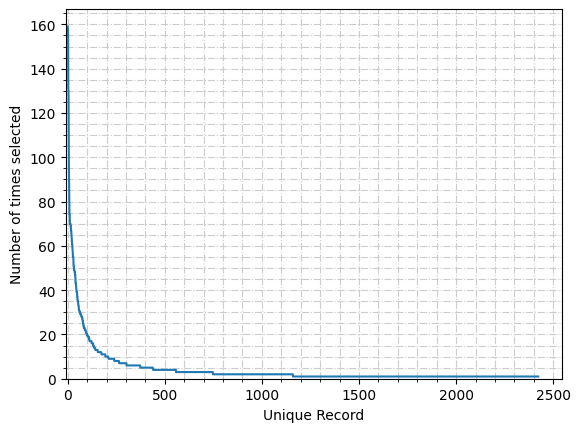

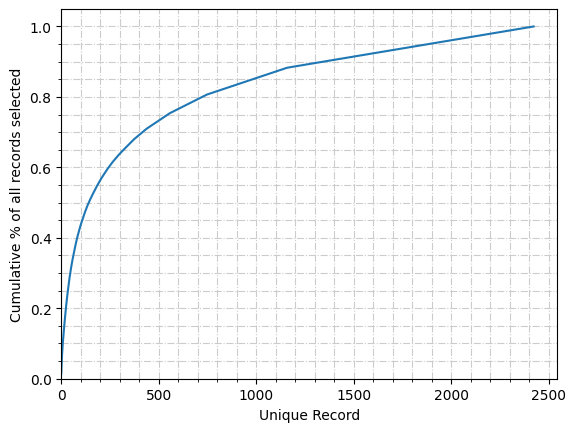

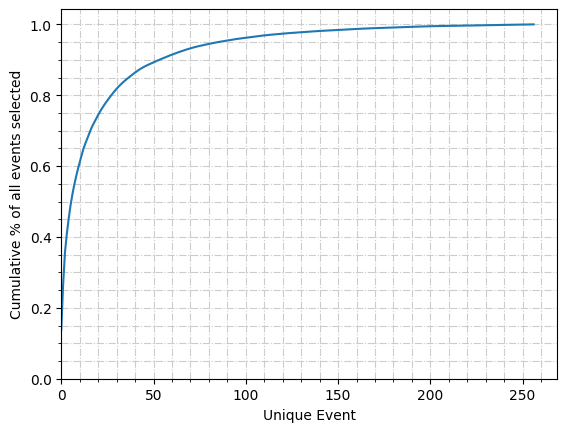

In [17]:
fig, ax3 = plt.subplots()
ax3.plot(recs_and_events["count"].to_numpy())
ax3.grid(True, which="both", ls="-.", color="0.8")
ax3.minorticks_on()
ax3.set_xlabel("Unique Record")
ax3.set_ylabel("Number of times selected")
ax3.set_ylim(0)
ax3.set_xlim(-10)

fig, ax1 = plt.subplots()
ax1.plot(recs_and_events["cum_%"].to_numpy())
ax1.grid(True, which="both", ls="-.", color="0.8")
ax1.minorticks_on()
ax1.set_xlabel("Unique Record")
ax1.set_ylabel("Cumulative % of all records selected")
ax1.set_ylim(0)
ax1.set_xlim(0)

fig, ax2 = plt.subplots()
ax2.plot(events["cum_%"].to_numpy())
ax2.grid(True, which="both", ls="-.", color="0.8")
ax2.minorticks_on()
ax2.set_xlabel("Unique Event")
ax2.set_ylabel("Cumulative % of all events selected")
ax2.set_ylim(0)
ax2.set_xlim(0)


In [18]:
cols_to_keep = [("metadata", "event_id"), ("metadata", "station_code"), ("metadata", "location_code")]
unique_esm_records = all_recs[all_recs[("metadata", "database")] == "ESM"]\
                     .drop_duplicates(subset=cols_to_keep)
unique_esm_records = unique_esm_records[cols_to_keep].reset_index(drop=True)
esm_records_to_download = unique_esm_records
esm_records_to_download.to_csv(esm_records_to_download_fp, index=False)

In [19]:
# For the NGASub records we need the NGAsubRSN for each combination of event_id and station_code
NGASub_records = all_recs[all_recs[("metadata", "database")] == "NGASub"]
unique_NGASub_id_counts = NGASub_records.groupby(
    [("metadata", "event_id"), ("metadata", "station_code")]).size().sort_values(ascending=False)
unique_NGASub_id_counts = unique_NGASub_id_counts.rename("count")

# load the NGASub database
ngasub_fp = cfg["raw_data"]["gm_flatfiles"] / "NGASub_Metadata_SA_rotD50.csv"
ngasub_db = pd.read_csv(ngasub_fp, header=0, encoding="cp1252", dtype=str)
new_index = list(ngasub_db[["NGAsubEQID", "NGAsubSSN"]].itertuples(index=False, name=None))
ngasub_db.index = new_index
ngasub_db = ngasub_db["NGAsubRSN"]

# RSNs to download
rsns_to_download = ngasub_db.loc[unique_NGASub_id_counts.index]
rsns_to_download = pd.concat([rsns_to_download, unique_NGASub_id_counts], axis=1)
rsns_to_download.to_csv(ngasub_records_to_download_fp, index=False)

In [20]:
# Per-campaign record-conversion list (record_identifier, component, database)
# for the AT2/HDF5 -> JSON converters. Combined across campaigns in
# wp1pt3pt8i-organise_records_to_download.
records_to_convert = (
    all_recs["metadata"][["record_identifier", "component", "database"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
records_to_convert.to_csv(
    cfg["proc_data"]["gm_selection"] / "AvgSA_06_records_to_convert.csv",
    index=False,
)
